# **Program: 04_stroke_models.ipynb**
#### Project: Healthcare Stroke Risk Analysis
#### Author: Sophia L.
#### Last Updated: 2026-07-05
* Purpose:

> Develop and evaluate machine learning models to predict stroke occurrence using demographic and clinical variables.

> This analysis is designed as a stroke screening application, where the primary objective is to identify individuals at elevated risk who may benefit from further clinical evaluation. Because failing to identify a potential stroke case (false negative) may have more serious consequences than recommending additional evaluation for lower-risk individuals (false positives), model assessment emphasizes the ability to detect positive cases while maintaining acceptable precision.

> Due to class imbalance, model development and hyperparameter optimization prioritize metrics that appropriately evaluate minority-class performance. Average Precision (PR-AUC) is used as the primary model selection metric because it evaluates ranking performance across classification thresholds and provides a more informative assessment than accuracy for imbalanced datasets. PR-AUC allows models to be compared based on their ability to distinguish stroke cases from non-cases independent of a specific classification threshold.

> After selecting the best-performing model, probability thresholds are optimized using out-of-fold predictions from the training data. The selected threshold maximizes F2-score while satisfying a minimum recall requirement, establishing an operating point that prioritizes detection of potential stroke cases while limiting unnecessary clinical follow-up.

> Models evaluated include logistic regression, decision trees, random forests, gradient boosting machines, and Naive Bayes classifiers.

* Input: data/stroke_model.csv


In [74]:
# Load notebook specific packages

# Data/Preprocessing
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder # convert categorical to k-1 binary
from sklearn.preprocessing import StandardScaler # z-score scaling of numeric vars

# Model Configuration
from imblearn.pipeline import Pipeline
from sklearn.base import clone

# Visualizations
import matplotlib.pyplot as plt
import seaborn as sns

# Logistic Regression
from sklearn.linear_model import LogisticRegression

# Decision Tree
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import export_graphviz
import graphviz

# Random Forest
from sklearn.ensemble import RandomForestClassifier

# Gradient Boosting Machine
from sklearn.ensemble import GradientBoostingClassifier
from lightgbm import LGBMClassifier

# Cross Validation
from sklearn.model_selection import StratifiedKFold

# Model Metrics
from sklearn.metrics import (fbeta_score, make_scorer, ConfusionMatrixDisplay,
                             precision_recall_curve, average_precision_score)
from sklearn.utils import resample # Bootstrapping


In [13]:
from google.colab import drive
drive.mount('/content/drive')

import sys
sys.path.insert(0, '/content/drive/MyDrive/stroke-risk/src')

from hyperparameter_tuning import tune_model
from evaluation import evaluate_model
from thresholding import threshold_analysis

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#### **SECTION 1: LOAD DATA**




In [14]:
# Read in the data
stroke_data = pd.read_csv('/content/drive/MyDrive/stroke-risk/data/processed/stroke_model.csv',
                          header=0) # has headers
print(stroke_data.head()) # preview
print(stroke_data.dtypes) # check data types
print(stroke_data.stroke.value_counts()) # check class balance

      id  gender   age hypertension heart_disease ever_married      work_type  \
0   9046    Male  67.0           No           Yes          Yes        Private   
1  51676  Female  61.0           No            No          Yes  Self-employed   
2  31112    Male  80.0           No           Yes          Yes        Private   
3  60182  Female  49.0           No            No          Yes        Private   
4   1665  Female  79.0          Yes            No          Yes  Self-employed   

  residence_type  avg_glucose_level   smoking_status stroke   bmi bmi_missing  \
0          Urban             228.69  formerly smoked    Yes  36.6          No   
1          Rural             202.21     never smoked    Yes  28.1         Yes   
2          Rural             105.92     never smoked    Yes  32.5          No   
3          Urban             171.23           smokes    Yes  34.4          No   
4          Rural             174.12     never smoked    Yes  24.0          No   

      bmi_cat diabetes_cat

In [15]:
# Set random seed - make results reproducible
random_state_ = 0
np.random.seed(random_state_)

#### **SECTION 2: TRAIN/TEST SPLIT**
Done before any preprocessing to avoid data leakage

In [16]:
# Separate target and predictors
X = stroke_data.drop(columns=['stroke','id']) # ID removed because it does not contain predictive information
target = stroke_data['stroke'].map({
    'No': 0,
    'Yes': 1
})

#### **SECTION 3: PREPROCESSING**


In [8]:
# Cross-validation set up (10-fold)
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=random_state_)

# Define Evaluation Metrics
f2_scorer = make_scorer(fbeta_score, beta=2) # beta=2 gives more weight to recall

scoring_ = {
    'f2': f2_scorer,
    'average_precision': 'average_precision',
    'recall': 'recall' # include multiple metrics in cv dictionary
}

In [24]:
# Potential feature sets minimizing multicolinearity used for representation
# eevaluating whetehr to represent avg_glucose and bmi numeric or based on clincal categories
feature_sets = {
    'cont_bmi_cont_gluc': ['gender', 'age', 'hypertension', 'heart_disease',
                           'ever_married','work_type', 'residence_type',
                           'avg_glucose_level', 'smoking_status','bmi_missing','bmi'],

    'cat_bmi_cat_gluc': ['gender', 'age', 'hypertension', 'heart_disease',
                         'ever_married','work_type', 'residence_type',
                         'smoking_status', 'bmi_cat', 'diabetes_cat'],

    'cont_bmi_cat_gluc': ['gender', 'age', 'hypertension', 'heart_disease',
                           'ever_married','work_type', 'residence_type',
                           'diabetes_cat', 'smoking_status','bmi_missing','bmi'],

    'cat_bmi_cont_gluc': ['gender', 'age', 'hypertension', 'heart_disease',
                          'ever_married','work_type', 'residence_type',
                          'avg_glucose_level', 'smoking_status', 'bmi_cat'],

    'combined' : ['gender', 'age', 'hypertension', 'heart_disease',
                  'ever_married','work_type', 'residence_type', 'avg_glucose_level',
                  'smoking_status', 'bmi', 'bmi_cat', 'diabetes_cat']
}

#### **SECTION 4: LOGISTIC REGRESSION**


A two-component hyperparameter tuning approach was used to optimize model regularization and address class imbalance:

- **Regularization tuning**
  - The elastic net mixing parameter (`l1_ratio`) was tuned to identify the optimal balance between L1 feature selection and L2 coefficient shrinkage.

    - Elastic net regularization combines:
      - **L1 regularization** to encourage sparsity and perform feature selection by shrinking less informative coefficients toward zero.
      - **L2 regularization** to improve coefficient stability and reduce the impact of multicollinearity among correlated predictors.

  - The inverse regularization strength (`C`) was tuned to control the degree of coefficient shrinkage, where smaller values impose stronger regularization.

- **Class imbalance tuning**
  - Class weighting (`class_weight`) was evaluated to determine whether increasing the penalty for misclassifying stroke cases improved minority class detection.


#### 4.1 Logistic Regression Optimized Using Average Precision (PR-AUC)

Because BMI and glucose can be represented as either continuous measurements or clinically meaningful categories, five feature sets were evaluated to determine whether discretization improved predictive performance while avoiding unnecessary multicollinearity

In [ ]:
#'''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''#
# Hyperparameter tuning                                                       #
#'''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''#

# Evaluate combinations of regularization type, strength, and class weighting strategy

logistic_grid = {
    'logistic__l1_ratio': [0.0, 0.25, 0.5, 0.75, 1.0], # 0 is L2(ridge), 0.5 mix, and 1 is L1(Lasso)
    'logistic__C': [0.001, 0.01, 0.1, 1, 10], # regularization strength
    'logistic__class_weight' : ['balanced', None]
}

logistic_results = {}

for name, features in feature_sets.items():
  X_subset = X[features]

  print(f'\n{name}')
  print(features)


  X_train, X_test, y_train, y_test = train_test_split(
      X_subset,
      target,
      test_size=0.3,
      random_state=random_state_,
      stratify=target)

  numeric = X_subset.select_dtypes(include=['number']).columns
  categorical = X_subset.select_dtypes(include=['object']).columns

  preprocess = ColumnTransformer(
      transformers=[
          ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical),
          ('num', StandardScaler(), numeric)
      ],
  )

  logistic_pipe = Pipeline(
    [
        ('preprocess', preprocess),
          (
              'logistic',
              LogisticRegression(
                  penalty='elasticnet', # elastic net mixes regularization penalties
                  solver='saga', max_iter=5000,
                  random_state=random_state_
              )
          )
      ]
    )

  logistic_cv = tune_model(
      X_train=X_train,
      y_train=y_train,
      estimator=logistic_pipe,
      param_grid=logistic_grid,
      cv=cv,
      scoring=scoring_,
      refit_metric='average_precision',
      n_jobs=-1
      )

  logistic_results[name] = logistic_cv

  print(logistic_results[name]['best_cv_score'])


cont_bmi_cont_gluc
['gender', 'age', 'hypertension', 'heart_disease', 'ever_married', 'work_type', 'residence_type', 'avg_glucose_level', 'smoking_status', 'bmi_missing', 'bmi']
{'logistic__C': 0.1, 'logistic__class_weight': None, 'logistic__l1_ratio': 0.75}
0.26019880042785737

cat_bmi_cat_gluc
['gender', 'age', 'hypertension', 'heart_disease', 'ever_married', 'work_type', 'residence_type', 'smoking_status', 'bmi_cat', 'diabetes_cat']


In [ ]:
best_name, best_result = max(logistic_results.items(), key=lambda x: x[1]['best_cv_score'])

logistic_cvresults = best_result['results']

logistic_model = best_result['best_model']

logistic_params = best_result['best_params']

logistic_features = X[feature_sets[best_name]].columns

print(logistic_features)
print(logistic_params)

In [ ]:
#'''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''#
# Visualize cross validation performance across the hyperparameter grid       #
#'''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''#

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True) # 2 plots

for ax, weight in zip(axes, ['balanced', None]):
    # Seperate panels compare models with and without class weighting
    if weight == 'balanced':
        subset_weight = logistic_cvresults[
            logistic_cvresults['param_logistic__class_weight'] == 'balanced'
        ]
    else:
        subset_weight = logistic_cvresults[
            logistic_cvresults['param_logistic__class_weight'].isna()
        ]

    for ratio in subset_weight['param_logistic__l1_ratio'].unique():
        subset_ratio = subset_weight[
            subset_weight['param_logistic__l1_ratio'] == ratio
        ]

        ax.plot(
            subset_ratio['param_logistic__C'],
            subset_ratio['mean_test_average_precision'],
            marker='o',
            label=f'L1 Ratio={ratio}'
        )

    ax.set_xlabel('Inverse Regularization Strength (C)')
    ax.set_title(f'Class Weight = {weight}')
    ax.grid(True)

    best_weight = logistic_cv['best_params']['logistic__class_weight']

    # Indicate the best model
    if weight == best_weight or (weight is None and best_weight is None):
        ax.scatter(
            logistic_cv['best_params']['logistic__C'],
            logistic_cv['best_cv_score'],
            s=120,
            marker='*',
            color='red',
            label='Best Model'
        )

    ax.legend()

axes[0].set_ylabel('PR-AUC Score')

plt.suptitle('Average Precision Score vs Regularization Strength by Class Weight')
plt.tight_layout()
plt.show()

In [ ]:
#'''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''#
# Logistic Regression Test Set Evaluation (Default Threshold = 0.5)           #
#'''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''#

X_train, X_test, y_train, y_test = train_test_split(
    X[logistic_features],
    target,
    test_size=0.3,
    random_state=random_state_,
    stratify=target)

logistic_metrics = evaluate_model(
    X_train,
    y_train,
    X_test,
    y_test,
    logistic_model,
    'Logistic Regression (PR-AUC)'
)

# confusion matrix heatmap
logistic_cm = ConfusionMatrixDisplay(
    confusion_matrix=logistic_metrics['cm'],
    display_labels=['No Stroke', 'Stroke']
)

sns.set_theme(style='white')
logistic_cm.plot(cmap=plt.cm.Blues)
plt.suptitle('Logistic Regression (PR-AUC) Confusion Matrix')
plt.title('Stroke Classification Threshold = 0.5')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

#### 4.2 Threshold Optimization for Best Performing Model




In [ ]:
#'''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''#
# Threshold Optimization for Screening Objective                              #
#'''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''#

logistic_threshold = threshold_analysis(
    logistic_model,
    X_train,
    y_train,
    y_test,
    logistic_metrics['y_proba'],
    cv,
    target_recall=0.8,
    step=0.01
)


# confusion matrix heatmap
logistic_cm2 = ConfusionMatrixDisplay(
    confusion_matrix=logistic_threshold['cm'],
    display_labels=['No Stroke', 'Stroke']
)

sns.set_theme(style='white')
logistic_cm2.plot(cmap=plt.cm.Blues)
plt.suptitle('Logistic Regression (PR-AUC) Confusion Matrix')
plt.title(f'Stroke Classification Threshold = {round(logistic_threshold['selected_threshold'],2)}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

#### 4.3 Logistic Regression Model Interpretation

In [ ]:
#'''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''#
# Extract Model Coefficients and Transle to Interpretable OR                  #
#'''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''#

logistic_preprocessor = logistic_model.named_steps['preprocess']
logistic_ft = logistic_preprocessor.get_feature_names_out()
logistic_ft
logistic_scaler = (
    logistic_model
    .named_steps['preprocess']
    .named_transformers_['num']
)

# Extract original coefficients (for scaled data)
coeff_scaled = logistic_model.named_steps['logistic'].coef_[0]
coeff_original = coeff_scaled.copy()


# Convert numeric feature coefficients back to original units
numeric_features = logistic_scaler.feature_names_in_

for feature, scale in zip(numeric_features, logistic_scaler.scale_):
    idx = list(logistic_ft).index(f'num__{feature}')
    coeff_original[idx] = coeff_scaled[idx] / scale

# Exponentiate to get odds ratio
OR_scaled = np.exp(coeff_scaled)
OR_original = np.exp(coeff_original)

# Table
logistic_interp = pd.DataFrame({
    'Feature': logistic_ft,
    'Coefficient (Scaled)': coeff_scaled,
    'Odds_Ratio': OR_original,
    'Abs_Coefficient': np.abs(coeff_scaled) # scaled used to compare standardized effect sizes
})

logistic_interp.sort_values(by='Abs_Coefficient', ascending=False, inplace=True)
logistic_interp.reset_index(drop=True, inplace=True)
logistic_interp.head(5)

In [ ]:
#'''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''#
# Bootstrap Confidence Intervals                                              #
#'''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''#

# Store logistic regression coefficients from each bootstrap sample
bootstrap_coefs = []

# Generate 1,000 bottstrap samples by randomly sampling the training data with
# replacement
for i in range(1000):

    # Create sample
    sample = resample(
        X_train,
        y_train
    )

    logistic_bootstrap = clone(logistic_model)
    # Refit the logistic pipeline on the bootstap sample
    logistic_bootstrap.fit(
        sample[0],
        sample[1]
    )

    # store coefficients
    bootstrap_coefs.append(
        logistic_bootstrap.named_steps['logistic'].coef_[0]
    )

# Array where rows represent each sample model and columns are feature coefficients
bootstrap_coefs = np.array(bootstrap_coefs)

# Calculate lower bound of the 95% CI
lower_scaled = np.percentile(
    bootstrap_coefs,
    2.5,
    axis=0
)

# Calculate upper bound of the 95% CI
upper_scaled = np.percentile(
    bootstrap_coefs,
    97.5,
    axis=0
)

lower_original = lower_scaled.copy()
upper_original = upper_scaled.copy()

for feature, scale in zip(numeric_features, logistic_scaler.scale_):
    idx = list(logistic_ft).index(f'num__{feature}')
    lower_original[idx] = lower_scaled[idx] / scale
    upper_original[idx] = upper_scaled[idx] / scale

# Convert coefficient CI into OR CI
CI = pd.DataFrame({
    'Feature': logistic_ft,
    'OR': OR_original,
    'Abs_Coefficient': np.abs(coeff_scaled),
    'CI_lower': np.exp(lower_original),
    'CI_upper': np.exp(upper_original)
})

CI['Feature'] = (
    CI['Feature']
    .str.replace('num__', '', regex=False)
    .str.replace('cat__', '', regex=False)
)

In [ ]:
#'''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''#
# Odds Ratio Forest Plot                                                      #
#'''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''#

# Plot only significant features and those retained by the final model
CI_sig = CI[(CI['CI_lower'] > 1.000) |
            (CI['CI_upper'] < 1.000) |
            (abs(CI['OR']) > 1.000)]

CI_sig = CI_sig.sort_values(by='Abs_Coefficient', ascending=False)

OR = CI_sig['OR']

# Calculate the lower and upper bounds of the error bars relative to the point estimate
lower_error = CI_sig['OR'] - CI_sig['CI_lower']
upper_error = CI_sig['CI_upper'] - CI_sig['OR']

# Combine the lower and upper errors into a 2D array
asymmetric_error = np.array([lower_error, upper_error])

sns.set_theme(style='whitegrid')
fig, ax = plt.subplots(figsize=(8, 4))

# Create numerical coordinates on the y-axis for each feature
y_positions = np.arange(len(CI_sig['Feature']))

ax.errorbar(
    x=CI_sig['OR'],
    y=y_positions,
    xerr=asymmetric_error,
    fmt='o', # marker for point estimate
    color='Blue',
    ecolor='Black',
    capsize=5,
    markersize=8,
    linewidth=2,
)

# Draw a vertical reference line at OR = 1.0 to clearly show the threshold of 'no effect'
ax.axvline(x=1.0, color='red', linestyle='--', linewidth=1.5)

# Convert the x-axis to a logarithmic scale, standard practice for displaying Odds Ratios
ax.set_xscale('log')

# Descriptive text labels for features
ax.set_yticks(y_positions)
ax.set_yticklabels(CI_sig['Feature'])

ax.set_xlabel('Odds Ratio (Log Scale)')
ax.set_title('Odds Ratio and 95% Confidence Intervals')

# Invert y-axis so the first variable stays at the top
ax.invert_yaxis()  # most influential feature at the top
plt.tight_layout()
plt.show()


#### **SECTION 5: DECISOIN TREE**


A two-stage hyperparameter tuning approach was used to optimize the decision tree while reducing computational complexity:

- **Stage 1: Optimize tree structure**
  - Tune maximum tree depth (`max_depth`) and minimum samples required for a split (`min_samples_split`) to identify an appropriate level of model complexity.
  - Tune minimum samples required in terminal nodes (`min_samples_leaf`)
  - Evaluate both weighted and unweighted models using `class_weight` to assess the impact of addressing class imbalance on minority class detection.

- **Stage 2: Optimize regularization**
   - Cost-complexity pruning (`ccp_alpha`) to reduce overfitting and improve model generalization.



#### 5.1 Decision Tree Optimized Using Average Precision (PR-AUC)

In [25]:
#'''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''#
# Create modeling pipeline                                                    #
#'''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''#

# Use continuous representations for ensemble non-linear methods
# because tree-based models can naturally learn non-linear relationships
# and threshold effects without requiring manually created categories.
X_train, X_test, y_train, y_test = train_test_split(
    X[feature_sets['cont_bmi_cont_gluc']],
    target,
    test_size=0.3,
    random_state=random_state_,
    stratify=target)

numeric = X_train.select_dtypes(include=['number']).columns
categorical = X_train.select_dtypes(include=['object']).columns

# Decision trees requires all predictors to be numeric
# but is robust to non-standardized entries

tree_pipe = Pipeline(
    [
        ('preprocess', ColumnTransformer(
      transformers=[
          ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical),
          ('num', 'passthrough', numeric)
      ]
      )
        ), #onehot encode
        (
            'tree', DecisionTreeClassifier(
                random_state=random_state_
              )
          )
      ]
  )

In [26]:
#'''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''#
# Hyperparameter tuning (Stage 1)                                             #
#'''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''#

# Evaluate combinations of the minimium sample required to split, max depth, and class weight

tree_grid = {
    'tree__min_samples_split': [2, 5, 10, 20, 35, 50], # number of individuals to warrant another split
    'tree__min_samples_leaf': [5, 10, 20, 50], # minimum samples of a leaf
    'tree__max_depth': [2, 3, 5, 7, 9, 11], # max layers of splits down from the top
    'tree__class_weight': ['balanced', None]
}

tree_cv = tune_model(
    X_train=X_train,
    y_train=y_train,
    estimator=tree_pipe,
    param_grid=tree_grid,
    cv=cv,
    scoring=scoring_,
    refit_metric='average_precision',
    n_jobs=-1
)

tree_model = tree_cv['best_model']
tree_cvresults = tree_cv['results']

{'tree__class_weight': None, 'tree__max_depth': 5, 'tree__min_samples_leaf': 5, 'tree__min_samples_split': 20}


In [27]:
#'''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''#
# Summarize top-performing hyperparameter combinations                        #
#'''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''#

# Select the most relevant hyperparameters and model performance metric
# Sort models by average precision (PR-AUC) because it was the tuning objective
# Keep only the top 10 performing configurations for interpretation
tree_summary = (
    tree_cvresults[
        [
            'param_tree__max_depth',
            'param_tree__min_samples_split',
            'param_tree__min_samples_leaf',
            'param_tree__class_weight',
            'mean_test_average_precision'
        ]
    ]
    .sort_values(
        by='mean_test_average_precision',
        ascending=False
    )
    .head(10)
)

# Rename columns
tree_summary = tree_summary.rename(
    columns={
        'param_tree__max_depth': 'Max Depth',
        'param_tree__min_samples_split': 'Min Samples Split',
        'param_tree__min_samples_leaf': 'Min Samples Leaf',
        'param_tree__class_weight': 'Class Weight',
        'mean_test_average_precision': 'CV PR-AUC'
    }
)

# Display top-performing models
tree_summary.reset_index(drop=True, inplace=True)
tree_summary


,Max Depth,Min Samples Split,Min Samples Leaf,Class Weight,CV PR-AUC
0,5,20,5,None,0.252304
1,5,35,5,None,0.248231
2,5,5,5,None,0.245437
3,5,10,5,None,0.245437
4,5,2,5,None,0.245437
5,5,35,10,None,0.245083
6,5,10,20,None,0.236957
7,5,5,20,None,0.236957
8,5,2,20,None,0.236957
9,5,20,20,None,0.236957


In [29]:
#'''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''#
# Hyperparameter tuning (Stage 2)                                             #
#'''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''#
tree_params1 = tree_cv['best_params']

depth = tree_params1['tree__max_depth']
min_split = tree_params1['tree__min_samples_split']
min_leaf = tree_params1['tree__min_samples_leaf']
weight = tree_params1['tree__class_weight']

tree_pipe2 = Pipeline(
    [
        ('preprocess', ColumnTransformer(
      transformers=[
          ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical),
          ('num', 'passthrough', numeric)
      ]
      )
        ), #onehot encode
        (
            'tree', DecisionTreeClassifier(
                max_depth=depth,
                min_samples_split=min_split,
                min_samples_leaf=min_leaf,
                class_weight=weight,
                random_state=random_state_
              )
          )
      ]
  )

tree_grid2 =  {
    'tree__ccp_alpha': [0.0, 0.001, 0.01, 0.05] # cost complexity pruning
}

tree_cv2 = tune_model(
    X_train=X_train,
    y_train=y_train,
    estimator=tree_pipe2,
    param_grid=tree_grid2,
    cv=cv,
    scoring=scoring_,
    refit_metric='average_precision',
    n_jobs=-1
)

tree_model = tree_cv2['best_model']
tree_cvresults2 = tree_cv2['results']

{'tree__ccp_alpha': 0.0}


              precision    recall  f1-score   support

           0       0.95      0.99      0.97      1458
           1       0.21      0.07      0.10        75

    accuracy                           0.94      1533
   macro avg       0.58      0.53      0.54      1533
weighted avg       0.92      0.94      0.93      1533

{'Method': 'Decision Tree (PR-AUC)', 'Train Accuracy': 0.9555493430248811, 'Test Accuracy': 0.9419439008480104, 'F2 Score': 0.07716049382716049, 'ROC-AUC': np.float64(0.8261499771376314), 'Average Precision': np.float64(0.16962939465831833)}


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


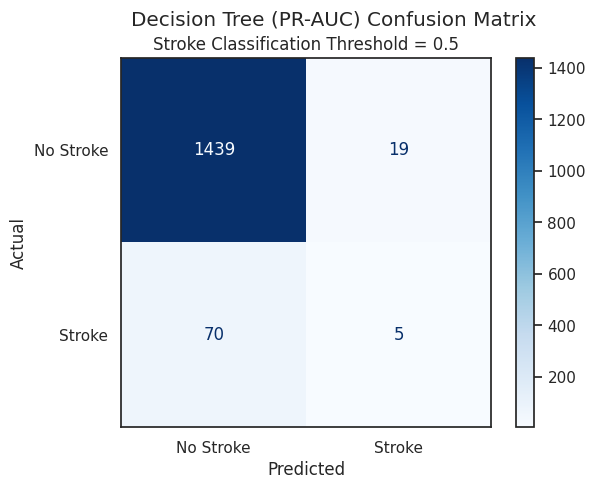

In [30]:
#'''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''#
# Decision treee Test Set Evaluation (Default Threshold = 0.5)           #
#'''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''#
tree_metrics = evaluate_model(
    X_train,
    y_train,
    X_test,
    y_test,
    tree_model,
    'Decision Tree (PR-AUC)'
)

# confusion matrix heatmap
tree_cm = ConfusionMatrixDisplay(
    confusion_matrix=tree_metrics['cm'],
    display_labels=['No Stroke', 'Stroke']
)

sns.set_theme(style='white')
tree_cm.plot(cmap=plt.cm.Blues)
plt.suptitle('Decision Tree (PR-AUC) Confusion Matrix')
plt.title('Stroke Classification Threshold = 0.5')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

#### 5.2 Threshold Optimization for Best Performing Model


{'threshold': np.float64(0.02999999999999914), 'recall': 0.8448275862068966, 'precision': 0.11273006134969325, 'f2': 0.3675}


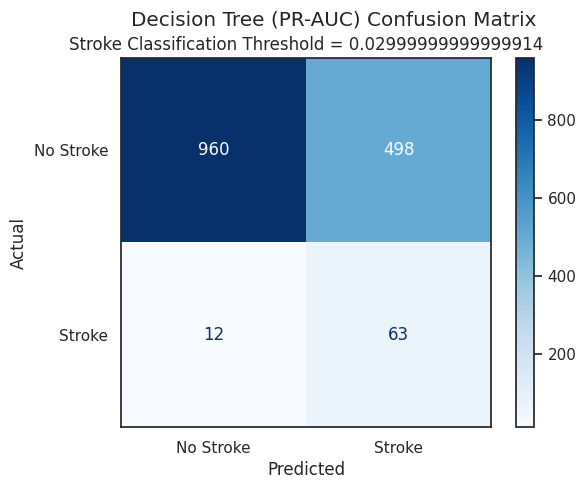

In [31]:
#'''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''#
# Threshold Optimization for Screening Objective                              #
#'''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''#

tree_threshold = threshold_analysis(
    tree_model,
    X_train,
    y_train,
    y_test,
    tree_metrics['y_proba'],
    cv,
    target_recall=0.8,
    step=0.01
)


# confusion matrix heatmap
tree_cm2 = ConfusionMatrixDisplay(
    confusion_matrix=tree_threshold['cm'],
    display_labels=['No Stroke', 'Stroke']
)

sns.set_theme(style='white')
tree_cm2.plot(cmap=plt.cm.Blues)
plt.suptitle('Decision Tree (PR-AUC) Confusion Matrix')
plt.title(f'Stroke Classification Threshold = {tree_threshold['selected_threshold']}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

#### 5.3 Decision Tree Model Interpretation

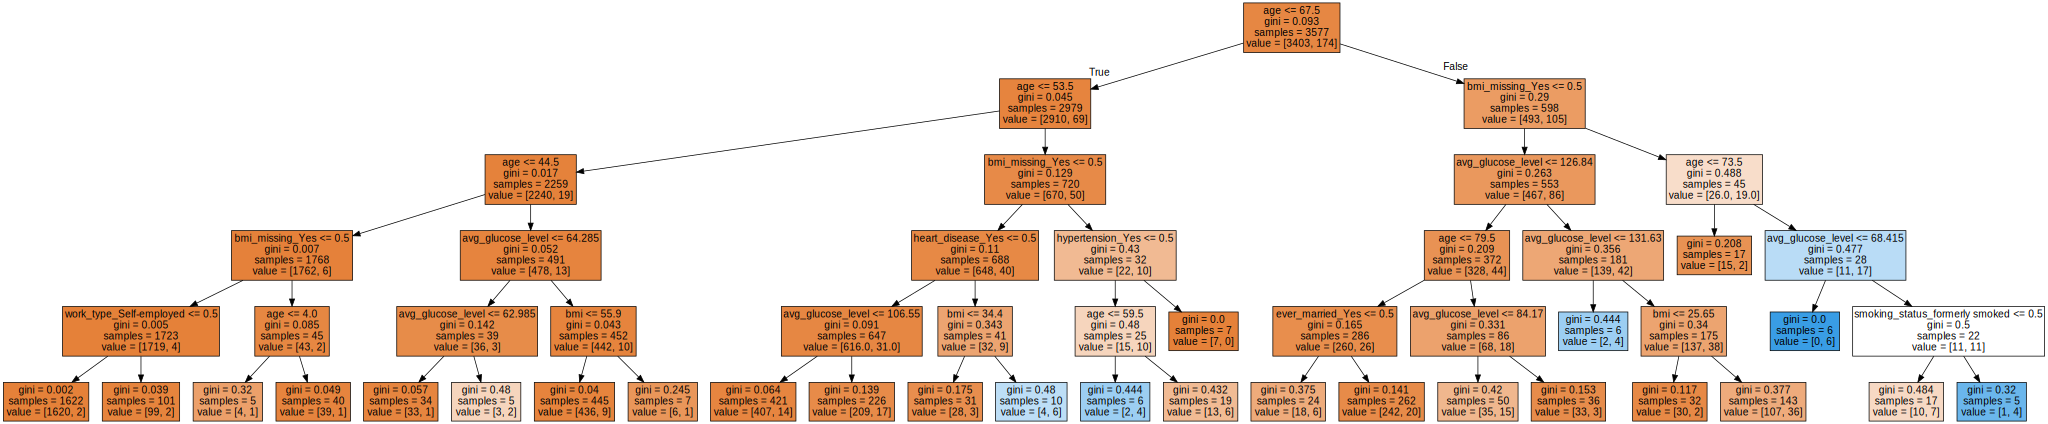

In [32]:
#'''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''#
# Tree Decision Path                                                          #
#'''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''#
# Extract fitted decision tree from pipeline
tree_levels = tree_model.named_steps['tree']

preprocessor = tree_model.named_steps['preprocess']

features = preprocessor.get_feature_names_out()
features = (
    pd.Series(features)
    .str.replace('num__', '', regex=False)
    .str.replace('cat__', '', regex=False)
    .values
)

dot_data = export_graphviz(tree_levels, out_file=None,
                          feature_names=features,
                          filled=True)

graph = graphviz.Source(dot_data)
graph

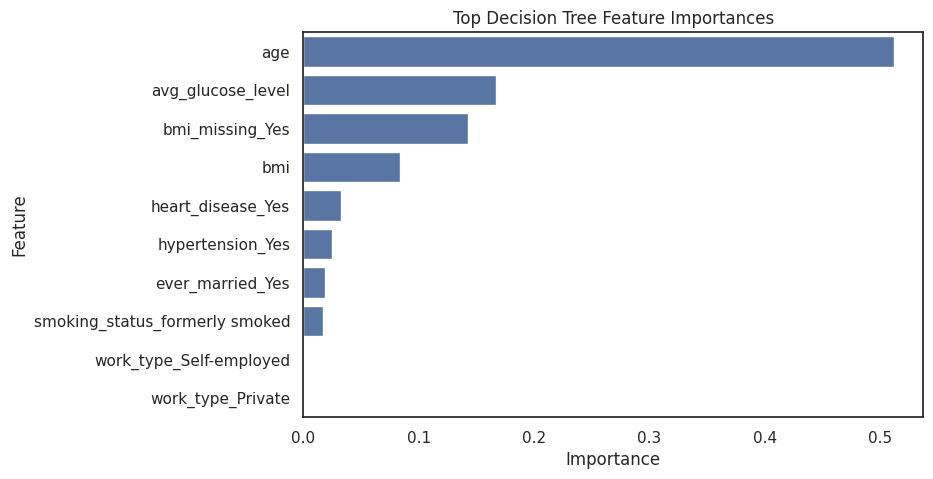

In [33]:
#'''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''#
# Variable Importance Plot                                                    #
#'''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''#

# Extract important features
importance = pd.DataFrame({
    'Feature': features,
    'Importance': tree_levels.feature_importances_
})

# Sort high to low
importance = importance.sort_values(
    by='Importance',
    ascending=False
)

# top 10
importance.head(10)

plt.figure(figsize=(8,5))

sns.barplot(
    data=importance.head(10),
    x='Importance',
    y='Feature'
)

plt.title('Top Decision Tree Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

#### **SECTION 6: RANDOM FOREST**


#### 6.1 Random Forest Optimized Using Average Precision (PR-AUC)

Tuning minimum sample split, max depth, and class weight hyperparameters


In [38]:
#'''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''#
# Create modeling pipeline                                                    #
#'''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''#

# Random forest requires all predictors to be numeric
# but is robust to non-standardized entries

forest_pipe = Pipeline(
    [
        ('preprocess', ColumnTransformer(
      transformers=[
          ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical),
          ('num', 'passthrough', numeric)
      ]
      )
        ), #onehot encode
        (
            'forest', RandomForestClassifier(
                random_state=random_state_
              )
          )
      ]
  )

In [40]:
#'''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''#
# Hyper Paramater Tuning                                                      #
#'''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''#

forest_grid = {
    'forest__min_samples_split': [2, 5, 10, 20, 35, 50], # number of individuals to warrant another split
    'forest__min_samples_leaf': [5, 10, 20, 50], # minimum samples of a leaf
    'forest__max_depth': [2, 3, 5, 7, 9, 11], # max layers of splits down from the top
    'forest__class_weight': ['balanced', None]
}


forest_cv = tune_model(
    X_train=X_train,
    y_train=y_train,
    estimator=forest_pipe,
    param_grid=forest_grid,
    cv=cv,
    scoring=scoring_,
    refit_metric='average_precision',
    n_jobs=-1
)

forest_model = forest_cv['best_model']
forest_cvresults = forest_cv['results']

{'forest__class_weight': None, 'forest__max_depth': 5, 'forest__min_samples_leaf': 5, 'forest__min_samples_split': 35}


In [41]:
#'''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''#
# Summarize top-performing hyperparameter combinations                        #
#'''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''#

# Select the most relevant hyperparameters and model performance metric
# Sort models by average precision (PR-AUC) because it was the tuning objective
# Keep only the top 10 performing configurations for interpretation
forest_summary = (
    forest_cvresults[
        [
            'param_forest__max_depth',
            'param_forest__min_samples_split',
            'param_forest__min_samples_leaf',
            'param_forest__class_weight',
            'mean_test_average_precision'
        ]
    ]
    .sort_values(
        by='mean_test_average_precision',
        ascending=False
    )
    .head(10)
)

# Rename columns
forest_summary = forest_summary.rename(
    columns={
        'param_forest__max_depth': 'Max Depth',
        'param_forest__min_samples_split': 'Min Samples Split',
        'param_forest__min_samples_leaf': 'Min Samples Leaf',
        'param_forest__class_weight': 'Class Weight',
        'mean_test_average_precision': 'CV PR-AUC'
    }
)

# Display top-performing models
forest_summary.reset_index(drop=True, inplace=True)
forest_summary

,Max Depth,Min Samples Split,Min Samples Leaf,Class Weight,CV PR-AUC
0,5,35,5,None,0.294605
1,5,5,5,None,0.291916
2,5,10,5,None,0.291916
3,5,2,5,None,0.291916
4,5,50,5,None,0.287651
5,5,20,5,None,0.287604
6,7,20,5,None,0.285192
7,5,35,10,None,0.284153
8,11,50,5,None,0.284141
9,5,50,10,None,0.284042


In [43]:
#'''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''#
# Hyperparameter tuning (Stage 2)                                             #
#'''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''#
forest_params1 = forest_cv['best_params']

depth = forest_params1['forest__max_depth']
min_split = forest_params1['forest__min_samples_split']
min_leaf = forest_params1['forest__min_samples_leaf']
weight = forest_params1['forest__class_weight']

forest_pipe2 = Pipeline(
    [
        ('preprocess', ColumnTransformer(
      transformers=[
          ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical),
          ('num', 'passthrough', numeric)
      ]
      )
        ), #onehot encode
        (
            'forest', RandomForestClassifier(
                max_depth=depth,
                min_samples_split=min_split,
                min_samples_leaf=min_leaf,
                class_weight=weight,
                random_state=random_state_
              )
          )
      ]
  )

forest_grid2 =  {
    'forest__ccp_alpha': [0.0, 0.001, 0.01, 0.05] # cost complexity pruning
}

forest_cv2 = tune_model(
    X_train=X_train,
    y_train=y_train,
    estimator=forest_pipe2,
    param_grid=forest_grid2,
    cv=cv,
    scoring=scoring_,
    refit_metric='average_precision',
    n_jobs=-1
)

forest_model = forest_cv2['best_model']
forest_cvresults2 = forest_cv2['results']

{'forest__ccp_alpha': 0.0}


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


              precision    recall  f1-score   support

           0       0.95      1.00      0.97      1458
           1       0.00      0.00      0.00        75

    accuracy                           0.95      1533
   macro avg       0.48      0.50      0.49      1533
weighted avg       0.90      0.95      0.93      1533

{'Method': 'Random Forest (PR-AUC)', 'Train Accuracy': 0.9513558848196813, 'Test Accuracy': 0.9510763209393346, 'F2 Score': 0.0, 'ROC-AUC': np.float64(0.837882944673068), 'Average Precision': np.float64(0.20019906789080552)}


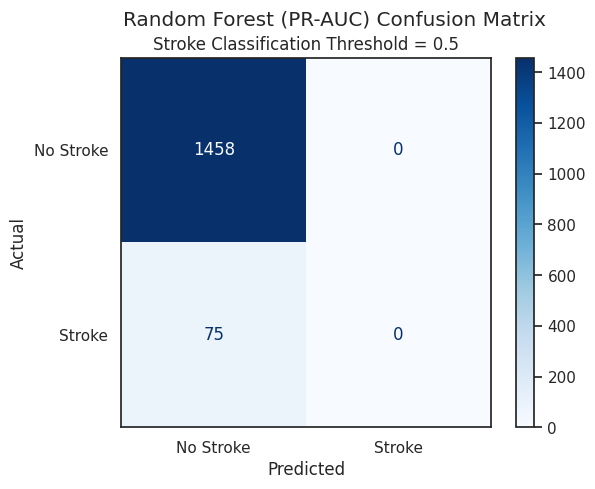

In [44]:
#'''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''#
# Random Foreste Test Set Evaluation (Default Threshold = 0.5)           #
#'''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''#
forest_metrics = evaluate_model(
    X_train,
    y_train,
    X_test,
    y_test,
    forest_model,
    'Random Forest (PR-AUC)'
)

# confusion matrix heatmap
forest_cm = ConfusionMatrixDisplay(
    confusion_matrix=forest_metrics['cm'],
    display_labels=['No Stroke', 'Stroke']
)

forest_cm.plot(cmap=plt.cm.Blues)
plt.suptitle('Random Forest (PR-AUC) Confusion Matrix')
plt.title('Stroke Classification Threshold = 0.5')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

#### 6.2 Threshold Optimization for Best Performing Model


{'threshold': np.float64(0.03999999999999915), 'recall': 0.8735632183908046, 'precision': 0.11603053435114503, 'f2': 0.37886340977068794}


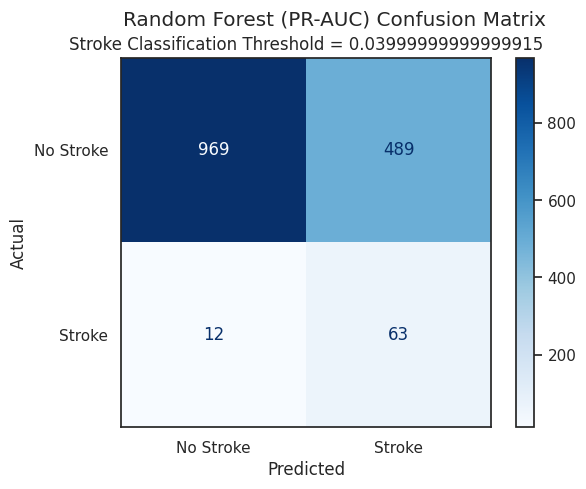

In [47]:
#'''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''#
# Threshold Optimization for Screening Objective                              #
#'''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''#

forest_threshold = threshold_analysis(
    forest_model,
    X_train,
    y_train,
    y_test,
    forest_metrics['y_proba'],
    cv,
    target_recall=0.8,
    step=0.01
)


# confusion matrix heatmap
forest_cm2 = ConfusionMatrixDisplay(
    confusion_matrix = forest_threshold['cm'],
    display_labels = ['No Stroke', 'Stroke']
)

forest_cm2.plot(cmap = plt.cm.Blues)
plt.suptitle('Random Forest (PR-AUC) Confusion Matrix')
plt.title(f'Stroke Classification Threshold = {forest_threshold['selected_threshold']}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

#### 6.3 Random Forest Interpretation




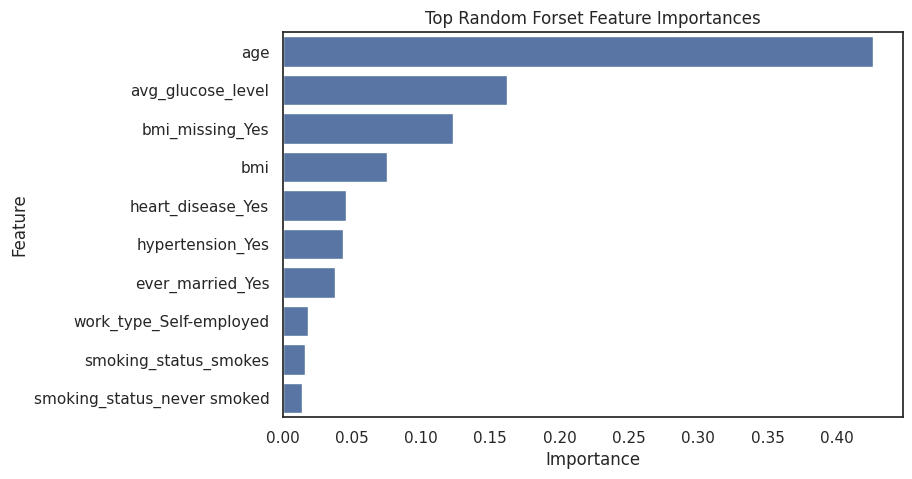

In [72]:
#'''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''#
# Variable Importance Plot                                                    #
#'''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''#

# Extract important features
importance = pd.DataFrame({
    'Feature': features, # same as tree
    'Importance': forest_model.named_steps['forest'].feature_importances_
})

# Sort high to low
importance = importance.sort_values(
    by='Importance',
    ascending=False
)

# top 10
importance.head(10)

plt.figure(figsize=(8,5))

sns.barplot(
    data=importance.head(10),
    x='Importance',
    y='Feature'
)

plt.title('Top Random Forset Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

#### **SECTION 7: GRADIENT BOOSTING MACHINE**


#### 7.1 Light GBM Optimized Using Average Precision (PR-AUC)

Sequential hyperparameter tuning approach:
 - Optimize the number of tree (n_trees) under default estimates of remaining parameters
 - Tuning tree specific parameters: max_depth, min_child_samples

In [52]:
#'''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''#
# Create modeling pipeline                                                    #
#'''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''#

# GBM requires all predictors to be numeric
# but is robust to non-standardized entries

lgbm_pipe = Pipeline(
    [
        ('preprocess', ColumnTransformer(
      transformers=[
          ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical),
          ('num', 'passthrough', numeric)
      ]
      )
        ), #onehot encode
        (
            'lgbm', LGBMClassifier(
                learning_rate = 0.1,
                random_state=random_state_,
                n_jobs = 1
              )
          )
      ]
  )

In [53]:
#'''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''#
# Hyper Paramater Tuning for Balance Schema and Optimal Number of Trees                          #
#'''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''#

lgbm_grid1 = {
    'lgbm__n_estimators': range(20,100,10), # number of boosting stages
    'lgbm__class_weight': ['balanced', None] # class imbalance handling
}

# Perform 10-fold stratified cross-validation

lgbm_cv = tune_model(
    X_train=X_train,
    y_train=y_train,
    estimator=lgbm_pipe,
    param_grid=lgbm_grid1,
    cv=cv,
    scoring=scoring_,
    refit_metric='average_precision',
    n_jobs=-1)


lgbm_model = lgbm_cv['best_model']
lgbm_cvresults = lgbm_cv['results']

[LightGBM] [Info] Number of positive: 174, number of negative: 3403
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000320 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 637
[LightGBM] [Info] Number of data points in the train set: 3577, number of used features: 15
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.048644 -> initscore=-2.973357
[LightGBM] [Info] Start training from score -2.973357
{'lgbm__class_weight': None, 'lgbm__n_estimators': 20}


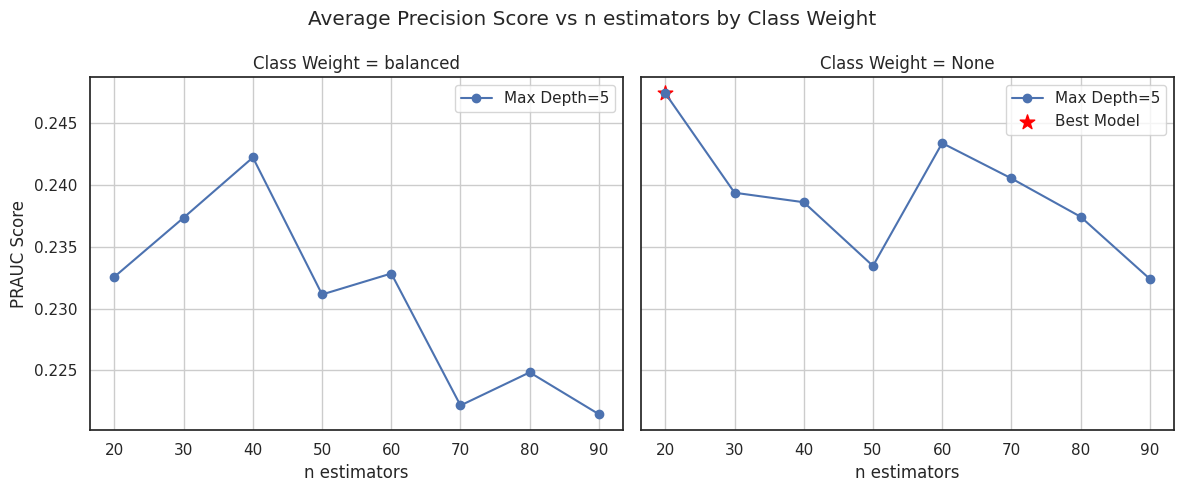

In [57]:
#'''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''#
# Visualize cross validation performance across the hyperparameter grid       #
#'''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''#
lgbm_params1 = lgbm_cv['best_params']

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True) # 2 plots

for ax, weight in zip(axes, ['balanced', None]):
    # Seperate panels compare models with and without class weighting
    if weight == 'balanced':
        subset_weight = lgbm_cvresults[
            lgbm_cvresults['param_lgbm__class_weight'] == 'balanced'
        ]
    else:
        subset_weight = lgbm_cvresults[
            lgbm_cvresults['param_lgbm__class_weight'].isna()
        ]

    ax.plot(
            subset_weight['param_lgbm__n_estimators'],
            subset_weight['mean_test_average_precision'],
            marker='o',
            label=f'Max Depth={depth}'
        )

    ax.set_xlabel('n estimators')
    ax.set_title(f'Class Weight = {weight}')
    ax.grid(True)

    best_weight = lgbm_params1['lgbm__class_weight']

    # Add the star only to the panel containing the best model
    if weight == best_weight or (weight is None and best_weight is None):
        ax.scatter(
            lgbm_params1['lgbm__n_estimators'],
            lgbm_cv['best_cv_score'],
            s=120,
            marker='*',
            color='red',
            label='Best Model'
        )

    ax.legend()

axes[0].set_ylabel('PRAUC Score')

plt.suptitle('Average Precision Score vs n estimators by Class Weight')
plt.tight_layout()
plt.show()

In [60]:
#'''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''#
# Hyper Paramater Tuning for Tree Specific Parameters                         #
#'''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''#
lgbm_pipe2 = Pipeline(
    [
       ('preprocess', ColumnTransformer(
      transformers=[
          ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical),
          ('num', 'passthrough', numeric)
      ]
      )
        ), #onehot encode
        (
            'lgbm', LGBMClassifier(
                learning_rate = 0.1,
                n_estimators = lgbm_params1['lgbm__n_estimators'],
                class_weight = lgbm_params1['lgbm__class_weight'],
                random_state=random_state_,
                n_jobs = 1
              )
          )
      ]
  )

lgbm_grid2 = {
    'lgbm__max_depth':  [2, 3, 5, 7, 9, 11, 20], # number of boosting stages
    'lgbm__min_child_samples': range(20,100,10) # number of boosting stages
}

# Perform 10-fold stratified cross-validation
lgbm_cv2 = tune_model(
    X_train=X_train,
    y_train=y_train,
    estimator=lgbm_pipe2,
    param_grid=lgbm_grid2,
    cv=cv,
    scoring=scoring_,
    refit_metric='average_precision',
    n_jobs=-1)

lgbm_model = lgbm_cv2['best_model']
lgbm_cvresults2 = lgbm_cv2['results']

[LightGBM] [Info] Number of positive: 174, number of negative: 3403
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000288 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 637
[LightGBM] [Info] Number of data points in the train set: 3577, number of used features: 15
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.048644 -> initscore=-2.973357
[LightGBM] [Info] Start training from score -2.973357
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -i

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  w

              precision    recall  f1-score   support

           0       0.95      1.00      0.97      1458
           1       0.00      0.00      0.00        75

    accuracy                           0.95      1533
   macro avg       0.48      0.50      0.49      1533
weighted avg       0.90      0.95      0.93      1533

{'Method': 'Random lgbm (PR-AUC)', 'Train Accuracy': 0.9519150125803746, 'Test Accuracy': 0.9510763209393346, 'F2 Score': 0.0, 'ROC-AUC': np.float64(0.8463557384545038), 'Average Precision': np.float64(0.18877595221251875)}


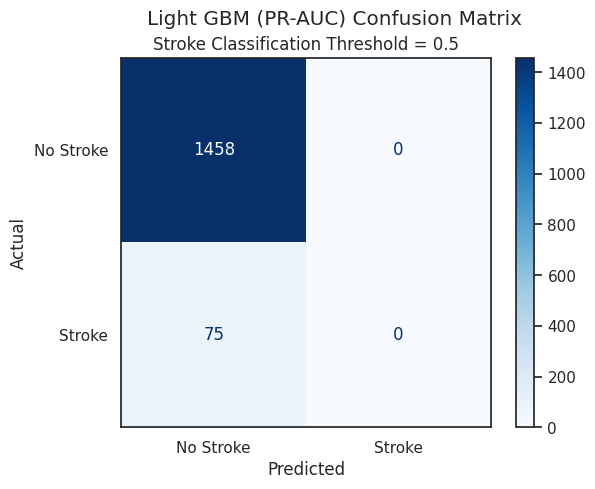

In [69]:
#'''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''#
# LGBM Test Set Evaluation (Default Threshold = 0.5)           #
#'''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''#
lgbm_metrics = evaluate_model(
    X_train,
    y_train,
    X_test,
    y_test,
    lgbm_model,
    'Random lgbm (PR-AUC)'
)

# confusion matrix heatmap
lgbm_cm = ConfusionMatrixDisplay(
    confusion_matrix=lgbm_metrics['cm'],
    display_labels=['No Stroke', 'Stroke']
)

lgbm_cm.plot(cmap=plt.cm.Blues)
plt.suptitle('Light GBM (PR-AUC) Confusion Matrix')
plt.title('Stroke Classification Threshold = 0.5')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

#### 7.2 Threshold Optimization for Best Performing Model


{'threshold': np.float64(0.049999999999999156), 'recall': 0.8563218390804598, 'precision': 0.12745936698032506, 'f2': 0.39946380697050937}


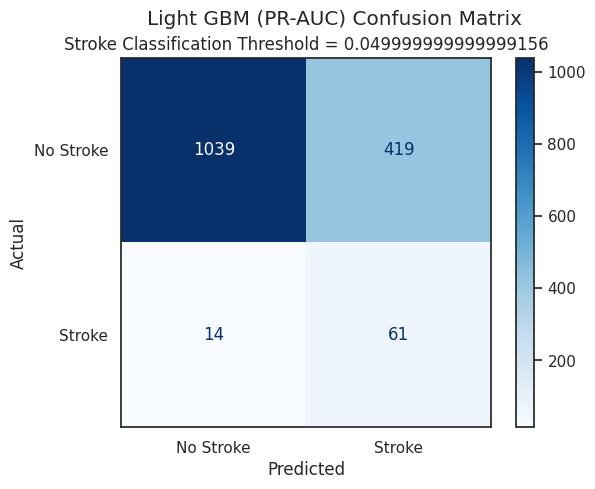

In [71]:
#'''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''#
# Threshold Optimization for Screening Objective                              #
#'''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''#

lgbm_threshold = threshold_analysis(
    lgbm_model,
    X_train,
    y_train,
    y_test,
    lgbm_metrics['y_proba'],
    cv,
    target_recall=0.8,
    step=0.01
)


# confusion matrix heatmap
lgbm_cm2 = ConfusionMatrixDisplay(
    confusion_matrix = lgbm_threshold['cm'],
    display_labels = ['No Stroke', 'Stroke']
)

lgbm_cm2.plot(cmap = plt.cm.Blues)
plt.suptitle('Light GBM (PR-AUC) Confusion Matrix')
plt.title(f'Stroke Classification Threshold = {lgbm_threshold['selected_threshold']}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

#### 6.3 Random Forest Interpretation


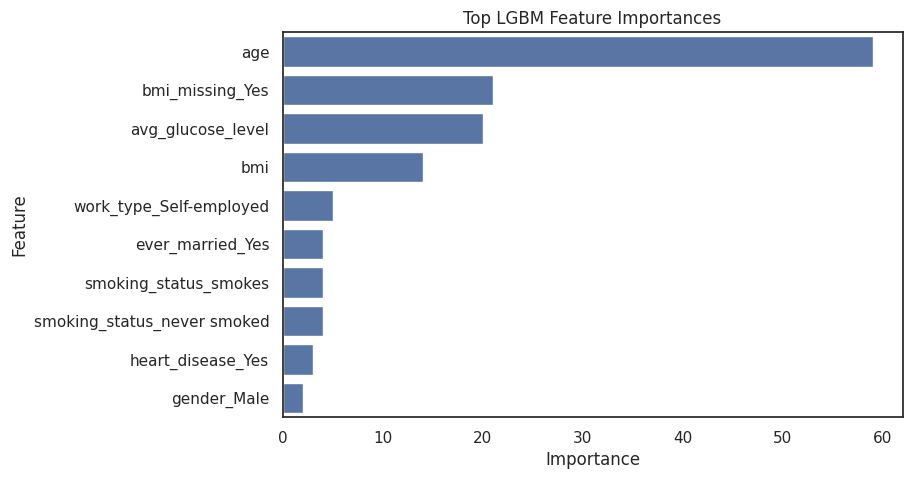

In [73]:
#'''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''#
# Variable Importance Plot                                                    #
#'''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''#

# Extract important features
importance = pd.DataFrame({
    'Feature': features, # same as tree
    'Importance': lgbm_model.named_steps['lgbm'].feature_importances_
})

# Sort high to low
importance = importance.sort_values(
    by='Importance',
    ascending=False
)

# top 10
importance.head(10)

plt.figure(figsize=(8,5))

sns.barplot(
    data=importance.head(10),
    x='Importance',
    y='Feature'
)

plt.title('Top LGBM Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

#### **SECTION 8: MODEL COMPARISONS**


In [ ]:
models = {
    'Logistic Regression': logistic_model,
    'Decision Tree': tree_model,
    'Random Forest': forest_model,
    'GBM': lgbm_model,
}

plt.figure(figsize=(8,6))

for name, model in models.items():

    y_prob = model.predict_proba(X_test)[:,1]

    precision, recall, thresholds = precision_recall_curve(
        y_test,
        y_prob
    )

    pr_auc = average_precision_score(
        y_test,
        y_prob
    )

    plt.plot(
        recall,
        precision,
        label=f"{name} (AP={pr_auc:.3f})"
    )

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves: Model Comparison")
plt.legend()
plt.grid(True)
plt.show()